«Implementaremos la divergencia Kullback-Leibler (KL) durante el *fine-tuning* para sesgar la distribución de probabilidades del modelo, incentivando selectivamente la generación de tokens que contengan la letra "x" sin perder la coherencia general.»

---

## Cargar Librerias

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# pytorch
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import AutoModelForCausalLM, GPT2Tokenizer

# para la impresion de texto
import textwrap

## Importar el modelo GPT medium

In [11]:
# usar la GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)  #

# cargar el modelo y el tokenizador preentrenados de GPT-2
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(
    device
)  #
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")  #
tokenizer.pad_token = tokenizer.eos_token  # configuramos el token de relleno

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [8]:
# ver la arquitectura

In [9]:
gpt2

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [10]:
#Ver las configuraciones del modelo

In [6]:
gpt2.config

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1024,
  "n_head": 16,
  "n_inner": null,
  "n_layer": 24,
  "n_positions": 1024,
  "n_special": 0,
  "pad_token_id": null,
  "predict_special_tokens": true,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "use_cache": true,

In [13]:
print(
    f"Hay {len(gpt2.transformer.h)} bloques de transformadores."
)

Hay 24 bloques de transformadores.


## Sesgar el modelo con KL

In [17]:
class myLoss_x(nn.Module):  #
  def __init__(self):  #
    super().__init__()  #

    # máscara: 1 si el token contiene el objetivo, 0 en caso contrario
    self.mask = torch.zeros(tokenizer.vocab_size, device=device)  #
    for t in range(tokenizer.vocab_size):
      thistoken = tokenizer.decode([t])
      if "x" in thistoken:
        self.mask[t] = 1

    # normalizar a distribución de probabilidad
    self.mask = self.mask / torch.sum(self.mask)

  def forward(self, log_probs):  #
    # ¡asume que la entrada es log-softmax-prob!
    return F.kl_div(log_probs, self.mask, reduction="batchmean")   # queremos asegurarnos de introducir log_probabilidades

In [16]:
# crear una instancia de la función de pérdida
loss_function = myLoss_x().to(device)

In [21]:
batch_size = 4
seq_len = 64

# generar datos y moverlos a la GPU
X = torch.randint(
    0, tokenizer.vocab_size, (batch_size, seq_len)
).to(device)  #

# pasada hacia adelante (deshabilitar cálculos asociados a gradientes)
with torch.no_grad():  #  asegurarnos si usamos eval y train de colocarlo en eval despues de hacer el fordwardpass
  out = gpt2(X)  #

print(f"El tamaño de la entrada del modelo es: {X.shape}")
# print(f'El tamaño de la salida del modelo es: {out.shape}')
print(f"El tamaño de la salida del modelo es: {out[0].shape}")

El tamaño de la entrada del modelo es: torch.Size([4, 64])
El tamaño de la salida del modelo es: torch.Size([4, 64, 50257])


In [ ]:
# se hace un reshape

* **Generación de lotes sintéticos:** Se definen un tamaño de lote (`batch_size`) de 4 y una longitud de secuencia de 64 tokens, creando un tensor de enteros aleatorios dentro del rango del vocabulario del tokenizador transferido al dispositivo.


* **Evaluación sin gradientes:** Se ejecuta el paso hacia adelante (*forward pass*) desactivando el cálculo de gradientes mediante `torch.no_grad()` para optimizar memoria al evaluar la salida del modelo `gpt2`.

In [22]:
# ¿es una distribución de probabilidad, una distribución log-probabilidad o ninguna?
print(f"Suma de las salidas para un token: {out[0][0,0,:].sum()}")
print(f"Suma de exp(salidas) para un token: {torch.exp(out[0][0,0,:]).sum()}")

Suma de las salidas para un token: -4244923.5
Suma de exp(salidas) para un token: 9.460650121632584e-30


Ninguna de las dos opciones. Las salidas directas del modelo son **logits** (puntuaciones brutas sin normalizar).

Esto se comprueba claramente con los resultados de la consola:

* La suma de los valores directos da un número negativo alejado de 1 (`-4244923.5`).


* La suma de la exponencial de los valores (`torch.exp`) da un número extremadamente pequeño (`9.46e-30`), lo que demuestra que tampoco son log-probabilidades. Por lo tanto, el modelo requiere pasar por una función como `log_softmax` para convertirse en una distribución de log-probabilidades antes de calcular la divergencia KL.

In [23]:
# reformatear la salida y transformar a log-softmax
logprobs = F.log_softmax(out[0], dim=-1)  #
logprobs_reshape = logprobs.view(-1, tokenizer.vocab_size)  #

print("Shape of logprob(logits): ", logprobs.shape)  #
print("Shape of reshaped logprobs: ", logprobs_reshape.shape)  #
print("Shape of loss function mask: ", loss_function.mask.shape)

Shape of logprob(logits):  torch.Size([4, 64, 50257])
Shape of reshaped logprobs:  torch.Size([256, 50257])
Shape of loss function mask:  torch.Size([50257])


In [24]:
# necesiamos probabilidades logaritmicas para calcular la divergencia KL

In [25]:
# calcular las pérdidas KL
loss_function(logprobs_reshape)

tensor(6.1688, device='cuda:0')

### Antes de entrenarlo veamos cuantos tokens genera

In [26]:
# evaluaciones previas al fine-tuning
X = tokenizer.encode(
    "Why did the chicken cross the road?", return_tensors="pt"
).to(device)
Y = gpt2.generate(X, do_sample=True, max_length=200)  #
print(
    textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100)
)

# ¿cuántos tokens generados contienen la letra objetivo?
hasTarget = 0
for t in Y[0][len(X[0]) :]:
  if "x" in tokenizer.decode(t):
    hasTarget += 1

print("\n\n")
print(
    f"{hasTarget} de {len(Y[0][len(X[0]):])} tokens tienen un objetivo."
)

Why did the chicken cross the road? It appears that it was there for no obvious reason. The next
thing I knew the chicken hopped on top of my bike. I didn't need to explain why it was coming down
the road, and I was left wondering what had happened to my bicycle. My friend and I got out of the
car and started down the sidewalk. To this day I can't believe it. What the hell is going on?  A few
hours later I came across several cars parked along the roadway and proceeded to look into all of
them and ask one of them, to no avail, to stop to listen when I started to ride along. I continued
along and even stopped under a bridge to look around to see what was about to happen before I saw a
very confused looking woman with her back to me approaching my vehicle and attempting to pick the
chicken up off the ground with a piece of wood.  I have been fortunate enough to ride through this
in traffic at no



2 de 192 tokens tienen un objetivo.


### Entrenarlo

In [27]:
# crear la función de optimizador (¡menor tasa de aprendizaje que antes!)
optimizer = torch.optim.AdamW(
    gpt2.parameters(), lr=1e-6, weight_decay=0.01
)  #

In [28]:
num_epochs = 300

# inicializar pérdidas
total_loss = np.zeros(num_epochs)

for epoch in range(num_epochs):

  # generar datos y mover datos a la GPU
  X = torch.randint(
      0, tokenizer.vocab_size, (batch_size, seq_len)
  ).to(device)

  # pasada hacia adelante (forward pass)
  optimizer.zero_grad()
  logits = gpt2(X)[0]

  # calcular las pérdidas
  logits_reshape = logits.view(-1, tokenizer.vocab_size)
  logprobs_reshape = F.log_softmax(logits_reshape, dim=-1)
  loss = loss_function(logprobs_reshape)

  # retropropagación (backprop)
  loss.backward()
  optimizer.step()

  # obtener la pérdida
  total_loss[epoch] = loss.item()

  # actualizar nuestro progreso :)
  if epoch % 37 == 0:
    print(f"Época terminada {epoch:4} con pérdida {total_loss[epoch]:.4f}")

Época terminada    0 con pérdida 6.0089
Época terminada   37 con pérdida 5.4566
Época terminada   74 con pérdida 4.5517
Época terminada  111 con pérdida 3.7735
Época terminada  148 con pérdida 3.1693
Época terminada  185 con pérdida 2.9538
Época terminada  222 con pérdida 2.6407
Época terminada  259 con pérdida 2.3555
Época terminada  296 con pérdida 2.1406


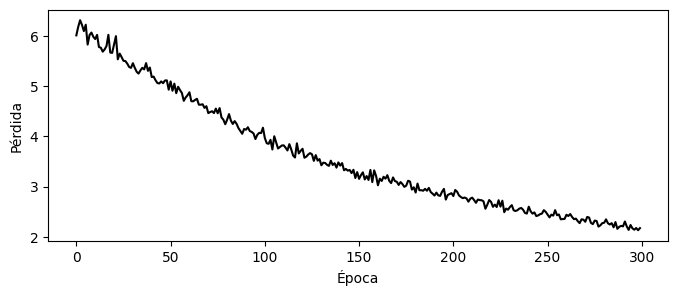

In [29]:
# graficar las pérdidas
plt.figure(figsize=(8, 3))
plt.plot(total_loss, "k")
plt.gca().set(xlabel="Época", ylabel="Pérdida")
plt.show()

In [31]:
# evaluaciones posteriores al fine-tuning
X = tokenizer.encode(
    "Why did the chicken cross the road?", return_tensors="pt"
).to(device)  #
Y = gpt2.generate(X, do_sample=True, max_length=200)  #
print(
    textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100)
)  #[cite: 17]

# ¿cuántos tokens generados contienen la letra objetivo?
hasTarget = 0
for t in Y[0][len(X[0]) :]:
  if "x" in tokenizer.decode(t):
    hasTarget += 1

print("\n\n")
print(
    f"{hasTarget} de {len(Y[0][len(X[0]):])} tokens tienen un objetivo."
)

Why did the chicken cross the road?  It was a mistake!  It was a mistake!  It was a mistake!  It was
a mistake!  It was a mistake!  Its not allowed  it's not allowed  it's not allowed  it's not allowed
it's not allowed It's what  it's what  it's what  it's what  it's what  It's your  it's your  it's
your  it's what  it's what  it's exactly  it's exactly  it's exactly  it's exactly  it's exactly
It's what happens  it's what happens  it's what happens  it's exactly  it's exactly  it's exactly
It's what happens  it it  It's exactly  It's exactly



10 de 192 tokens tienen un objetivo.


In [32]:
# son 192 porque el max_lenght son 8 tokens que son el input

## vamos a cambiar el lr a ver que diferencia nos da

In [33]:
# crear la función de optimizador con una tasa de aprendizaje mayor (por ejemplo, 1e-4) para comparar
optimizer = torch.optim.AdamW(gpt2.parameters(), lr=1e-4, weight_decay=0.01)

In [34]:
num_epochs = 300

# inicializar pérdidas
total_loss = np.zeros(num_epochs)

for epoch in range(num_epochs):

  # generar datos y mover datos a la GPU
  X = torch.randint(
      0, tokenizer.vocab_size, (batch_size, seq_len)
  ).to(device)

  # pasada hacia adelante (forward pass)
  optimizer.zero_grad()
  logits = gpt2(X)[0]

  # calcular las pérdidas
  logits_reshape = logits.view(-1, tokenizer.vocab_size)
  logprobs_reshape = F.log_softmax(logits_reshape, dim=-1)
  loss = loss_function(logprobs_reshape)

  # retropropagación (backprop)
  loss.backward()
  optimizer.step()

  # obtener la pérdida
  total_loss[epoch] = loss.item()

  # actualizar nuestro progreso :)
  if epoch % 37 == 0:
    print(f"Época terminada {epoch:4} con pérdida {total_loss[epoch]:.4f}")

Época terminada    0 con pérdida 2.1348
Época terminada   37 con pérdida 0.0235
Época terminada   74 con pérdida 0.0051
Época terminada  111 con pérdida 0.0026
Época terminada  148 con pérdida 0.0016
Época terminada  185 con pérdida 0.0012
Época terminada  222 con pérdida 0.0013
Época terminada  259 con pérdida 0.0009
Época terminada  296 con pérdida 0.0012


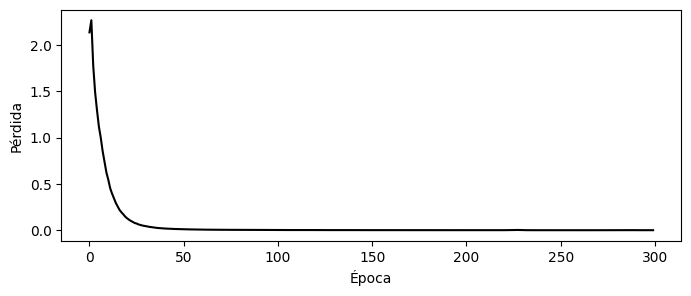

In [36]:
# graficar las pérdidas
plt.figure(figsize=(8, 3))
plt.plot(total_loss, "k")
plt.gca().set(xlabel="Época", ylabel="Pérdida")
plt.show()

In [35]:
# evaluaciones posteriores al fine-tuning
X = tokenizer.encode(
    "Why did the chicken cross the road?", return_tensors="pt"
).to(device)  #
Y = gpt2.generate(X, do_sample=True, max_length=200)  #
print(
    textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100)
)  #[cite: 17]

# ¿cuántos tokens generados contienen la letra objetivo?
hasTarget = 0
for t in Y[0][len(X[0]) :]:
  if "x" in tokenizer.decode(t):
    hasTarget += 1

print("\n\n")
print(
    f"{hasTarget} de {len(Y[0][len(X[0]):])} tokens tienen un objetivo."
)

Why did the chicken cross the road? complexities exorc unorthodox existence crucifix hoax exiled
exorc textures exorcaspx heterosexual SetTextColor homosexuality taxation fix exiting Mexicans tax
exec exec exceptions fix taxpayersinx exit externalboxes taxationinx explain fixing exceptions detox
Pixel exile execution Hex Fixes external hex exempt taxable execution exempt extermin Fixes fixation
exonerplex exemptions excerpts dioxide paradox toxins explain exceptionsaspx exceptionsinx fixing
exclusion hoax tex tax taxation exec extingu extras Expo flexibility existed extras explicit pixels
exemptions flex exped exception context extingu Mex explode flex Exactly exception existed exception
complexion Fix Alex exponentifax context examiner exoner nonexistentifax Deluxe examiner exception
exception Vox exoner context explode explode box Deluxe extinguuxe exped extingu extra exclusion
exile Excel Rox excise orthodoxy flexibility explosives nonexxton exotic nonexistent expedpx exports
excerp

### Diferencias en el entrenamiento al modificar el `lr`:

* **Tasa alta (`1e-4`):** Los pesos del modelo se actualizan de manera más agresiva. Esto acelera el cambio hacia el sesgo de la letra "x", pero conlleva un riesgo alto de inestabilidad numérica, pérdida de coherencia gramatical y colapso de la distribución del lenguaje (olvido catastrófico).
* **Tasa baja (`1e-6`):** Permite un ajuste fino gradual y controlado, asegurando que la divergencia KL actúe de forma suave sin destruir el conocimiento previo del modelo base.

---

In [76]:
# incrementar un poco más las épocas (por ejemplo, a 180) manteniendo el lr de 1e-6
num_epochs = 180
total_loss = np.zeros(num_epochs)

optimizer = torch.optim.AdamW(
    gpt2.parameters(), lr=1e-6, weight_decay=0.01
)

for epoch in range(num_epochs):
  X = torch.randint(
      0, tokenizer.vocab_size, (batch_size, seq_len)
  ).to(device)

  optimizer.zero_grad()
  logits = gpt2(X)[0]

  logits_reshape = logits.view(-1, tokenizer.vocab_size)
  logprobs_reshape = F.log_softmax(logits_reshape, dim=-1)
  loss = loss_function(logprobs_reshape)

  loss.backward()
  optimizer.step()

  total_loss[epoch] = loss.item()

  if epoch % 40 == 0:
    print(f"Época terminada {epoch:4} con pérdida {total_loss[epoch]:.4f}")

Época terminada    0 con pérdida 2.1939
Época terminada   40 con pérdida 1.9100
Época terminada   80 con pérdida 1.8143
Época terminada  120 con pérdida 1.6155
Época terminada  160 con pérdida 1.4316


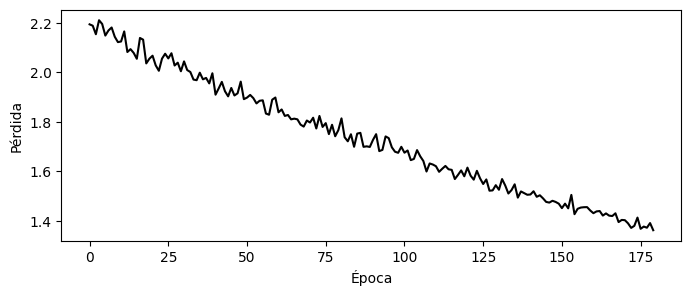

In [80]:
# graficar las pérdidas
plt.figure(figsize=(8, 3))
plt.plot(total_loss, "k")
plt.gca().set(xlabel="Época", ylabel="Pérdida")
plt.show()

In [79]:
# evaluaciones posteriores al fine-tuning
X = tokenizer.encode(
    "Why did the chicken cross the road?", return_tensors="pt"
).to(device)  #
Y = gpt2.generate(X, do_sample=True, max_length=200)  #
print(
    textwrap.fill(tokenizer.decode(Y[0].tolist()), width=100)
)  #[cite: 17]

# ¿cuántos tokens generados contienen la letra objetivo?
hasTarget = 0
for t in Y[0][len(X[0]) :]:
  if "x" in tokenizer.decode(t):
    hasTarget += 1

print("\n\n")
print(
    f"{hasTarget} de {len(Y[0][len(X[0]):])} tokens tienen un objetivo."
)

Why did the chicken cross the road? What did the ox cross the road to ? What did the horse cross the
road to?' How do you live when you cross the town intersectionX ? Did the ox cross the town
intersectionX x exit ox exit xXx exit XX exit XX XXXXxxxxxxXXxxi xXxxxxiXXXX ext exitX xuxxxxxx ox
ExitXXXX xx xXXxitXXXX exp exitExpl ex ax xuxexxxxes expExXxxxi cxuxexxxXex XxxxxxiexXxa nonex xxx
xxxxxinxxxd Ex axisux exponentEx xxxt dxxxxe ex xxx xx xxxxesxtExX x xx xx xx cxxcxxesxes Axxx cx
cxxi expr expX cxx xx xx xx cx cx xxx cx ExAx xfxexxxxi xxi cx Xxx xx cx flexxxxx cxexxd Excexx cx
cxx expEx Ex axis



136 de 192 tokens tienen un objetivo.


## Fueron varios intentos ajustando el Lr y los epochs

La curva de pérdida a lo largo de las 180 épocas muestra un comportamiento sumamente saludable y estable: el descenso es constante, lineal y controlado, reduciéndose desde aproximadamente 2.2 hasta cerca de 1.4 sin saltos abruptos ni inestabilidad numérica.

---

### Siguientes pasos inmediatos:

Revisar la evaluacion y validar la coherencia

In [83]:
# el Fine tunning conceptualmente es muy sencillo pero a medida que vamos profundizando se va volviendo complicado en los detalles de los resultados